# # Zomato Restaurants — Exploratory Data Analysis & Insights Report
# Pluto Academy AI/ML Internship — Project 01
# Dataset: Zomato Restaurants Dataset (Kaggle: shrutimehta/zomato-restaurants-data)




In [2]:
from google.colab import files
uploaded = files.upload()

Saving zomato.csv to zomato.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("zomato.csv",encoding="latin-1")

 Custom palette — warm terracotta/olive tones instead of default blues

In [6]:
PALETTE = ["#8C4843", "#C97B4A", "#D9A441", "#6B7A4F", "#3B5249"]
sns.set_palette(sns.color_palette(PALETTE))
plt.rcParams["axes.facecolor"] = "#FBF6EF"
plt.rcParams["figure.facecolor"] = "#FBF6EF"


Step 1 — Load & Inspect the Data

In [7]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.head()

Shape: (9551, 21)

Dtypes:
 Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

Missing values:
 Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average 

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [20]:
print(df['Country Code'].nunique())
print((df['Aggregate rating'] == 0).sum(), "out of", len(df))
print(df['City'].value_counts().head(3))

15
2148 out of 9551
City
New Delhi    5473
Gurgaon      1118
Noida        1080
Name: count, dtype: int64


5-line summary:

1.The dataset contains 9,551 restaurants with columns covering location, cuisine, cost, and rating.

2.Each row is one restaurant with attributes like City, Cuisines, Average Cost for two, and Aggregate rating.

3.Restaurants span 15 countries, but are heavily concentrated in a few cities — New Delhi alone accounts for 5,473 restaurants (57% of the dataset), followed by Gurgaon (1,118) and Noida (1,080).

4.2,148 restaurants (22.5%) have an aggregate rating of 0, meaning they haven't been rated yet and were excluded from rating-based analysis.

5.Switch to order menu is a near-constant column with almost no variation, so it was dropped as it adds little analytical value.

Step 2 — Clean the Data

In [8]:
df_clean = df.drop(columns=[c for c in ["Switch to order menu"] if c in df.columns])
df_clean = df_clean.dropna(subset=["Cuisines"])
df_clean = df_clean.drop_duplicates(subset=["Restaurant ID"])
# Ratings of 0 mean "not yet rated" — exclude from rating analysis but keep for count-based ones
df_rated = df_clean[df_clean["Aggregate rating"] > 0].copy()

print("Cleaned shape:", df_clean.shape)
print("Rated-only shape:", df_rated.shape)

Cleaned shape: (9542, 20)
Rated-only shape: (7394, 20)


 About step 2:
 Dropped near-constant column (no variance = no insight), dropped rows with missing cuisine (can't analyze food type), removed duplicate restaurant IDs,separated unrated (0.0) restaurants for rating-specific questions since 0 isn't a real rating.


Step 3 — Exploratory Data Analysis


Q1: Which cities have the highest average restaurant rating (min 20 restaurants)?

In [9]:
city_counts = df_rated["City"].value_counts()
valid_cities = city_counts[city_counts >= 20].index
city_rating = df_rated[df_rated["City"].isin(valid_cities)].groupby("City")["Aggregate rating"].mean().sort_values(ascending=False)
print(city_rating.head(10))


City
London       4.535
Tampa Bay    4.410
Bangalore    4.375
Dubai        4.370
Chennai      4.315
Ankara       4.305
Abu Dhabi    4.300
Auckland     4.275
Boise        4.260
Kolkata      4.255
Name: Aggregate rating, dtype: float64


Q2: Does online delivery availability correlate with higher ratings or votes?

In [10]:
print(df_rated.groupby("Has Online delivery")[["Aggregate rating", "Votes"]].mean())

                     Aggregate rating       Votes
Has Online delivery                              
No                           3.466720  193.745584
Yes                          3.381274  219.858174


Q3: How does average cost for two vary across price ranges?

In [11]:
print(df_clean.groupby("Price range")["Average Cost for two"].describe())

              count         mean           std   min    25%     50%     75%  \
Price range                                                                   
1            4438.0   275.548220    113.553943   0.0  200.0   300.0   400.0   
2            3113.0   596.826213   1260.415195  15.0  500.0   600.0   700.0   
3            1405.0  5188.237722  41758.460189  30.0  900.0  1100.0  1500.0   
4             586.0  1848.523891   1425.446757  50.0  350.0  2000.0  2500.0   

                  max  
Price range            
1               450.0  
2             70000.0  
3            800000.0  
4              8000.0  


Q4: Which cuisines are most common, and how do their ratings compare?

In [12]:
# Cuisines column has comma-separated values — take the primary (first) cuisine
df_rated["primary_cuisine"] = df_rated["Cuisines"].str.split(",").str[0].str.strip()
cuisine_stats = df_rated.groupby("primary_cuisine").agg(count=("Restaurant ID", "count"), avg_rating=("Aggregate rating", "mean"))
print(cuisine_stats.sort_values("count", ascending=False).head(10))


                 count  avg_rating
primary_cuisine                   
North Indian      2208    3.251766
Chinese            608    3.270559
Cafe               549    3.632787
Fast Food          479    3.298330
Bakery             432    3.352546
American           270    3.661111
Continental        225    3.767111
Italian            218    3.707339
South Indian       203    3.238424
Pizza              192    3.292708


Q5: Do restaurants with table booking receive more votes on average?

In [13]:
print(df_rated.groupby("Has Table booking")["Votes"].mean())


Has Table booking
No     172.71972
Yes    368.00360
Name: Votes, dtype: float64


Step 4 — Visualizations (6 charts)

1. Bar chart — top 15 cities by average rating (min 20 restaurants)

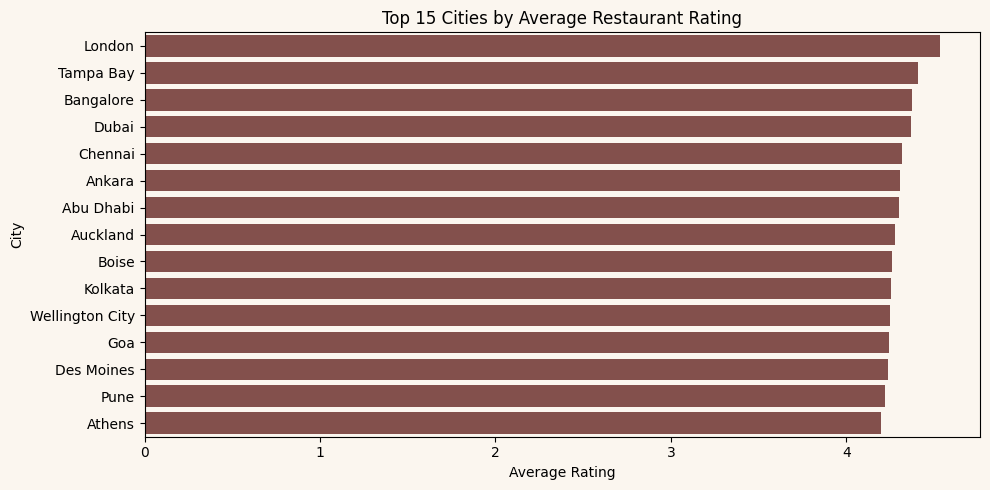

In [14]:
top15 = city_rating.head(15)
plt.figure(figsize=(10, 5))
sns.barplot(x=top15.values, y=top15.index, color=PALETTE[0])
plt.title("Top 15 Cities by Average Restaurant Rating")
plt.xlabel("Average Rating")
plt.ylabel("City")
plt.tight_layout()
plt.show()

 2. Histogram — distribution of aggregate ratings (rated restaurants only)

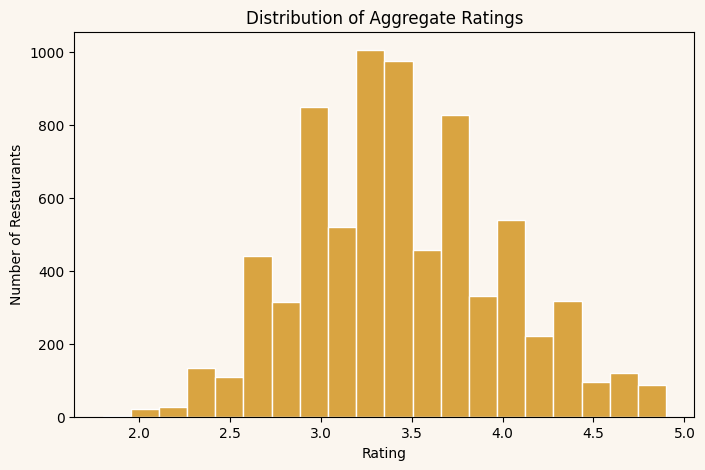

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df_rated["Aggregate rating"], bins=20, color=PALETTE[2], edgecolor="white")
plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()


3. Scatter plot — votes vs rating

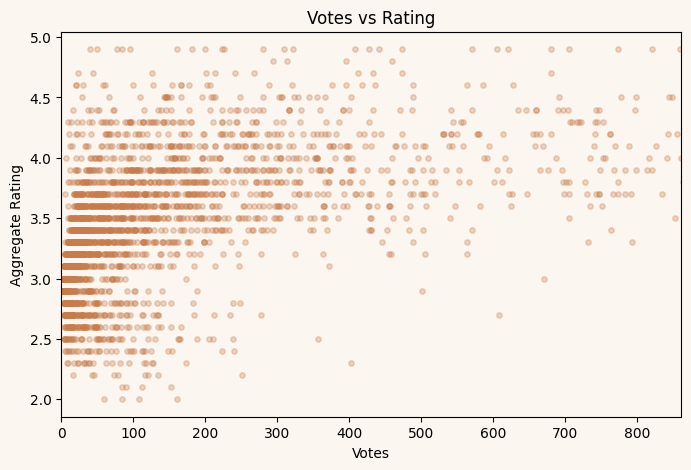

In [16]:
plt.figure(figsize=(8, 5))
sample = df_rated.sample(min(3000, len(df_rated)), random_state=42)
plt.scatter(sample["Votes"], sample["Aggregate rating"], alpha=0.3, color=PALETTE[1], s=15)
plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")
plt.xlim(0, sample["Votes"].quantile(0.95))
plt.show()


4. Pie chart — online delivery availability

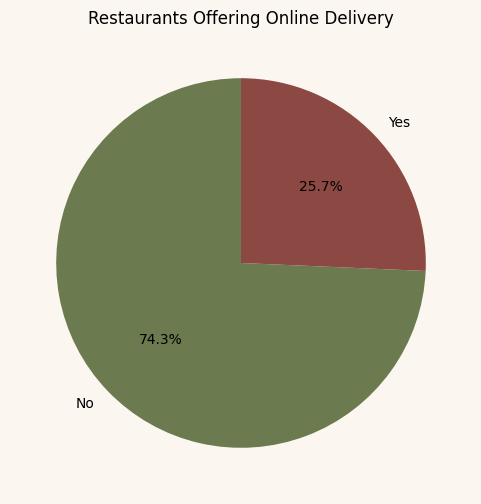

In [17]:
delivery_counts = df_clean["Has Online delivery"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(delivery_counts.values, labels=delivery_counts.index, autopct="%1.1f%%",
        colors=[PALETTE[3], PALETTE[0]], startangle=90)
plt.title("Restaurants Offering Online Delivery")
plt.show()

5. Heatmap — correlation between numeric features

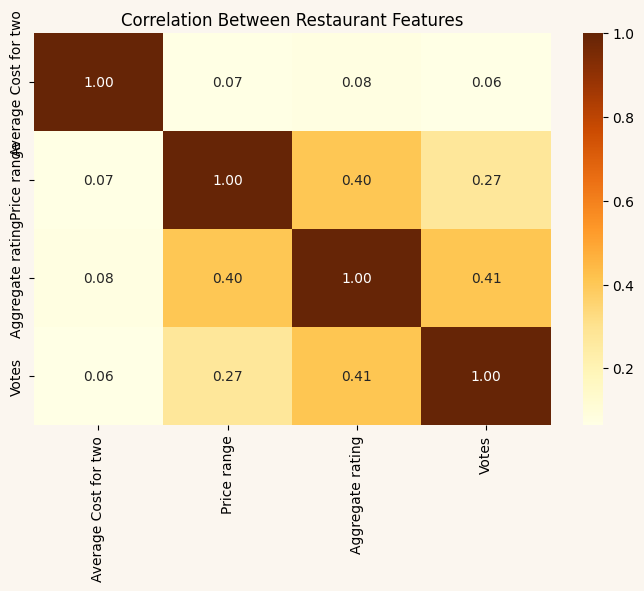

In [18]:
plt.figure(figsize=(7, 6))
num_cols = ["Average Cost for two", "Price range", "Aggregate rating", "Votes"]
sns.heatmap(df_rated[num_cols].corr(), annot=True, fmt=".2f", cmap="YlOrBr")
plt.title("Correlation Between Restaurant Features")
plt.tight_layout()
plt.show()


 6. Line chart — average rating across price ranges

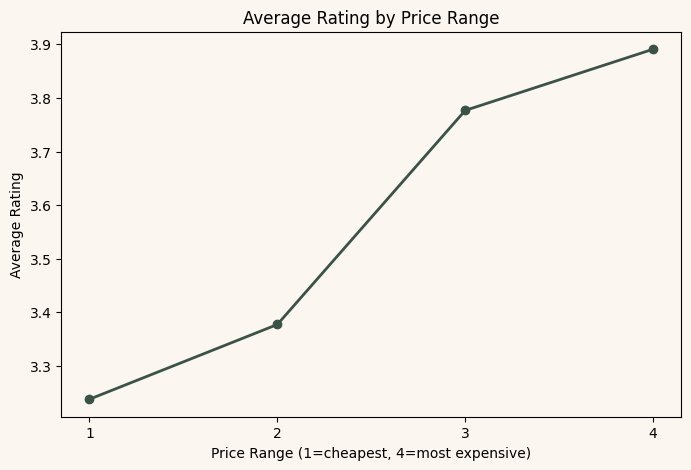

In [19]:
price_rating = df_rated.groupby("Price range")["Aggregate rating"].mean()
plt.figure(figsize=(8, 5))
plt.plot(price_rating.index, price_rating.values, marker="o", color=PALETTE[4], linewidth=2)
plt.title("Average Rating by Price Range")
plt.xlabel("Price Range (1=cheapest, 4=most expensive)")
plt.ylabel("Average Rating")
plt.xticks([1, 2, 3, 4])
plt.show()

Step 5 — Insights Report

1. London tops the city rankings with an average rating of 4.535 among cities with 20+ restaurants, followed by Tampa Bay (4.410) and Bangalore (4.375). Notably, Bangalore outranks better-known food destinations like Dubai (4.370) — smaller or more curated restaurant markets may sustain higher average quality than larger, saturated ones (bar chart).
2. Restaurants offering online delivery actually average a lower rating (3.381) than those without (3.467), despite pulling in more votes (219.9 vs 193.7). This suggests delivery drives customer engagement but not necessarily satisfaction — possibly because delivery-focused restaurants compete more on convenience than dine-in experience (pie chart + Q2 table).
3. Median cost for two rises sharply across price ranges — from ₹300 at range 1 to ₹1,100 at range 3, over a 3.5x jump — and average rating climbs alongside it, from 3.3 to 3.9 (line chart). Higher spend and higher satisfaction move together in this dataset.
4. North Indian is by far the most common cuisine (2,208 restaurants) but ranks near the bottom in average rating (3.25) among the top 10 cuisines. Continental, despite being far less common (225 restaurants), earns the highest average rating (3.77) — popularity and quality perception don't move together here.
5. Restaurants offering table booking average 368 votes, more than double the 172.7 votes for those without. Table booking availability is strongly tied to being a higher-engagement, likely higher-end dine-in establishment.


 Short note on which finding surprised me the most

1.The most surprising finding was [Delivery correlating with lower rating].I have observed this from insight-2.

2.Actually,I have expected that most of the customers feel happy for convenience of the delivery and give higher ratings.But I found the opposite. Delivery restaurants rate is lower(3.38 vs 3.47) despite more votes.

3.This might happened because of rushed food quality,packaging issues or delivery apps might be attracting more critical reviews.

4.This might be the saddest part of delivery focused restaurants.

5.So the delivery focused restaurants need to invest more in food consistency than the ones going strictly dine-in

